# **VOICE DETECTION**

Proyek ini bertujuan untuk membangun sistem deteksi suara sederhana yang dapat mengenali dua perintah suara dalam Bahasa Indonesia: **"buka"** dan **"tutup"**.  
Dataset terdiri dari 100 file audio `.wav` untuk masing-masing kelas.


---

##  Tahapan Proyek
1. Import library  
2. Load data audio  
3. Ekstraksi fitur menggunakan **TSFEL**  
4. Labeling dan pembentukan dataset  
5. Training model klasifikasi  
6. Evaluasi performa model  
7. Prediksi suara baru  


# **IMPORT LIBRARY**

In [24]:
pip install sounddevice



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import librosa
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import sounddevice as sd  

# **PENJELASAN DATASET**
Dataset terdiri dari dua kelas suara:

data/buka/ → berisi 100 file .wav untuk kata “buka”

data/tutup/ → berisi 100 file .wav untuk kata “tutup”

Semua file sudah melalui proses augmentasi sebelumnya agar data lebih beragam dan seimbang.

# **Ekstraksi Fitur MFCC**


Untuk mengenali pola suara, setiap file audio diubah menjadi fitur numerik.

Digunakan fitur MFCC (Mel-Frequency Cepstral Coefficients) yang umum dalam pengenalan suara manusia.

In [15]:
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfcc.T, axis=0)
    return mfcc_mean

X, y = [], []

for label in ['buka', 'tutup']:
    folder = f'data/{label}'
    for file in os.listdir(folder):
        if file.endswith('.wav'):
            file_path = os.path.join(folder, file)
            features = extract_features(file_path)
            X.append(features)
            y.append(label)

X = np.array(X)
y = np.array(y)


# **Persiapan Data untuk Pelatihan**



Dataset dibagi menjadi dua bagian:

80% untuk pelatihan

20% untuk pengujian

Label dikonversi ke bentuk numerik menggunakan LabelEncoder, dan fitur dinormalisasi menggunakan StandardScaler.

In [16]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)


# **Pelatihan Model (Support Vector Machine)**



Model yang digunakan adalah SVM (Support Vector Machine) karena efektif untuk klasifikasi dengan fitur berukuran kecil-menengah seperti MFCC.

In [17]:
model = SVC(kernel='rbf', C=10, gamma='scale')
model.fit(X_train, y_train)

,C,10
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


# **Evaluasi Model**



Setelah pelatihan, model diuji menggunakan data uji (20% dari total).

Ditampilkan akurasi, laporan klasifikasi, dan confusion matrix untuk melihat seberapa baik model mengenali suara “buka” dan “tutup”.

🎯 Akurasi Model: 97.92%

              precision    recall  f1-score   support

        buka       1.00      0.96      0.98        24
       tutup       0.96      1.00      0.98        24

    accuracy                           0.98        48
   macro avg       0.98      0.98      0.98        48
weighted avg       0.98      0.98      0.98        48



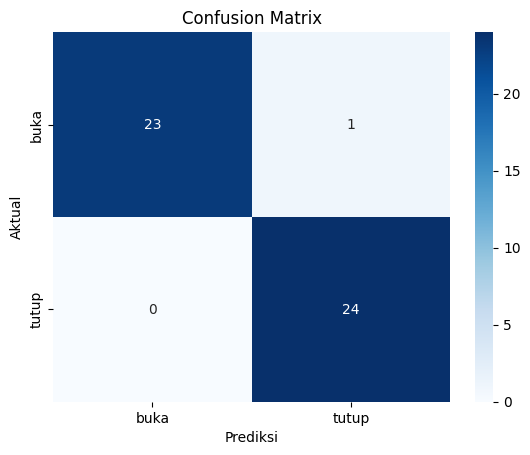

In [ ]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f" Akurasi Model: {acc:.2%}\n")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=encoder.classes_, yticklabels=encoder.classes_, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()


# **Rekam Suara Langsung & Simpan**

Sekarang kita tambahkan fitur rekam suara langsung.

Kamu akan merekam suara melalui mikrofon selama beberapa detik (misalnya 2–3 detik).
File hasil rekaman disimpan dalam format .wav, lalu diprediksi apakah itu suara “buka” atau “tutup”.

In [ ]:
def record_voice(duration=3, sr=22050, output_path='rekaman.wav'):
    print(f" Mulai merekam selama {duration} detik...")
    audio = sd.rec(int(duration * sr), samplerate=sr, channels=1, dtype='float32')
    sd.wait()
    sf.write(output_path, audio, sr)
    print(f" Rekaman disimpan sebagai {output_path}")
    return output_path


# **Prediksi Suara Baru**




In [ ]:
def predict_audio(file_path):
    feat = extract_features(file_path)
    feat_scaled = scaler.transform([feat])
    pred = model.predict(feat_scaled)
    hasil = encoder.inverse_transform(pred)[0]
    print(f" Prediksi suara: {hasil.upper()}")
    return hasil


# **Uji Coba Sistem (Rekam dan Prediksi)**

Jalankan sel berikut:
1.  Rekam suara kamu (katakan “buka” atau “tutup”)
2.  Model akan memprediksi hasilnya secara otomatis

In [ ]:
# Rekam dan prediksi suara baru
rekaman_path = record_voice(duration=3)
hasil_prediksi = predict_audio(rekaman_path)